#  Exploration des données (EDA) — Prédiction du Churn Client

**Objectif : analyser et visualiser la répartition des variables catégorielles et numériques en fonction de la variable cible `Churn`.**

---

##  Objectif du Notebook
Ce notebook est dédié à l’analyse exploratoire des données (EDA) du dataset de **churn client**.  
Il vise à :
- Comprendre la structure et le contenu du dataset
- Identifier les variables les plus pertinentes pour la prédiction du churn
- Explorer la répartition des variables catégorielles et continues selon la cible `Churn`


---



In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings("ignore")  # Masque tous les warnings


/kaggle/input/churn-client/telecom customers churn.csv


# EDA


In [2]:
# Importation et l'affichage the dataset 
df = pd.read_csv('/kaggle/input/churn-client/telecom customers churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Dimensions du dataset 
df.shape

(7043, 21)

In [4]:
# Affichage des colonne dans un liste
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
df.duplicated().sum()

0

In [6]:
# Informations sur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df = df.drop(columns=['customerID'])

In [8]:
# Convert Totalcharges to numeric 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
# Détecte les valeurs manquantes dans le dataset
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## Handling missing values

In [10]:

# Remplacer les NaN par la moyenne pour chaque colonne numérique
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())


In [11]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.shape

(7043, 20)

In [13]:
# Statistiques ()
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2265.000258
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1400.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# analyse simple et visualisations 

In [14]:

def plot_countplot(df, column, hue=None,title=None):
    
    plt.figure(figsize=(8, 5))
    sns.countplot(x=column, data=df, hue=hue)
    plt.title(title if title else f"Répartition de {column} selon le Churn")
    plt.xlabel(column)
    plt.ylabel("Nombre de counts")
    plt.show()


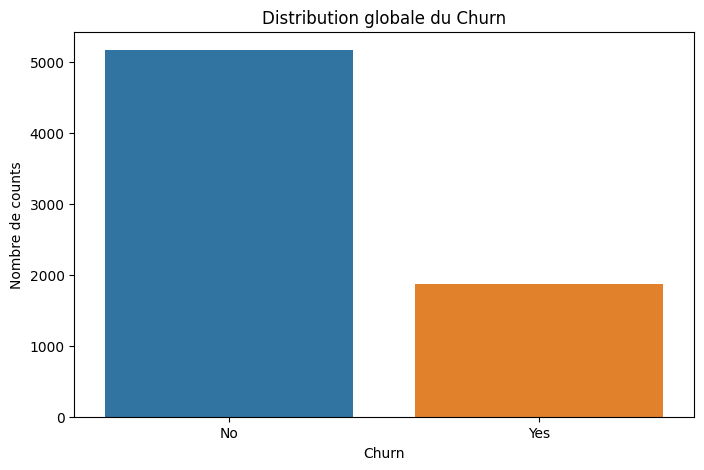

In [15]:
plot_countplot(df, column='Churn',title = "Distribution globale du Churn")

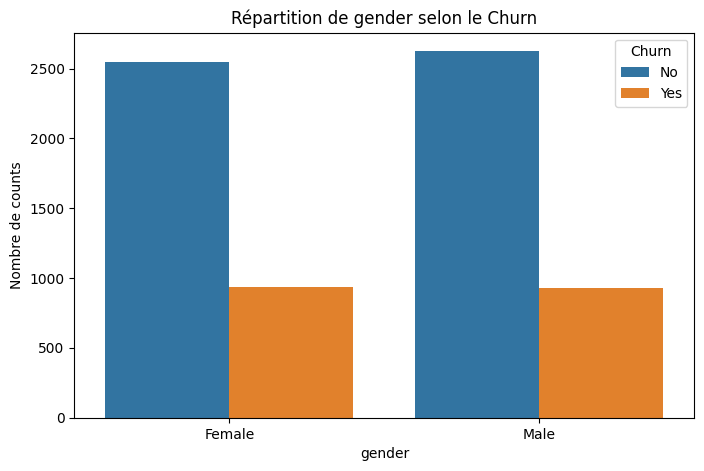

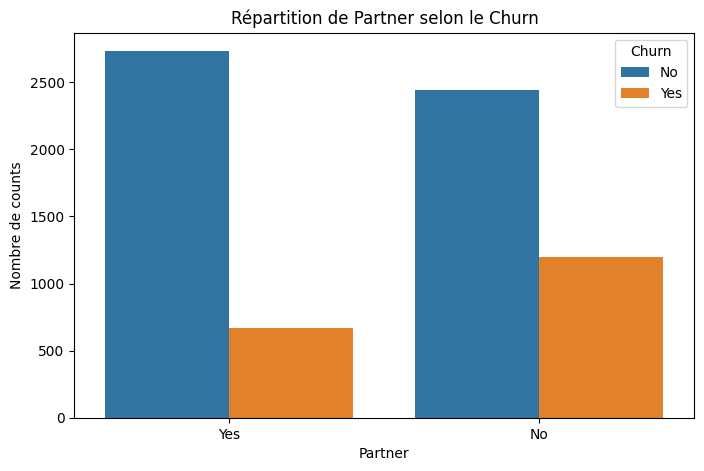

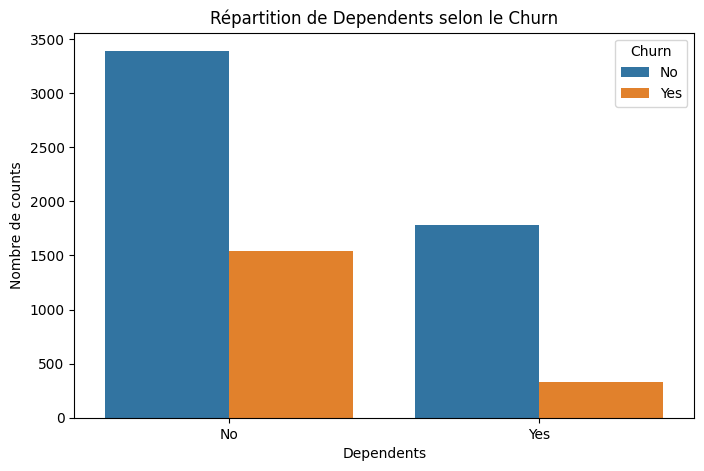

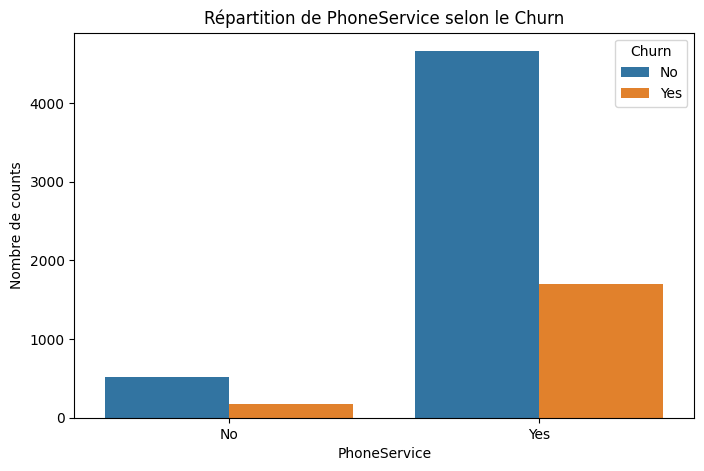

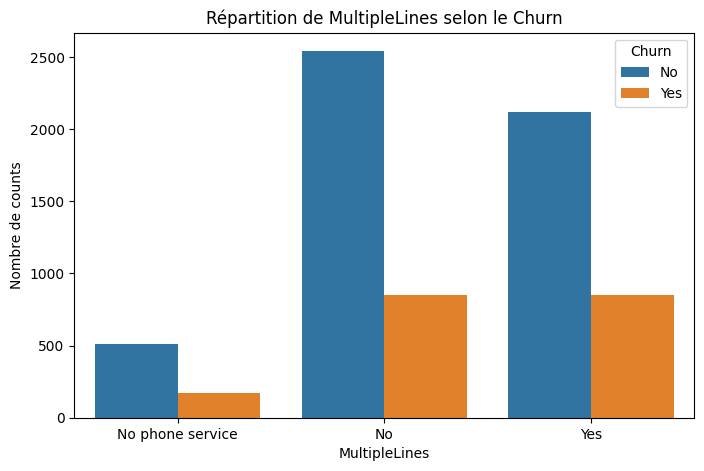

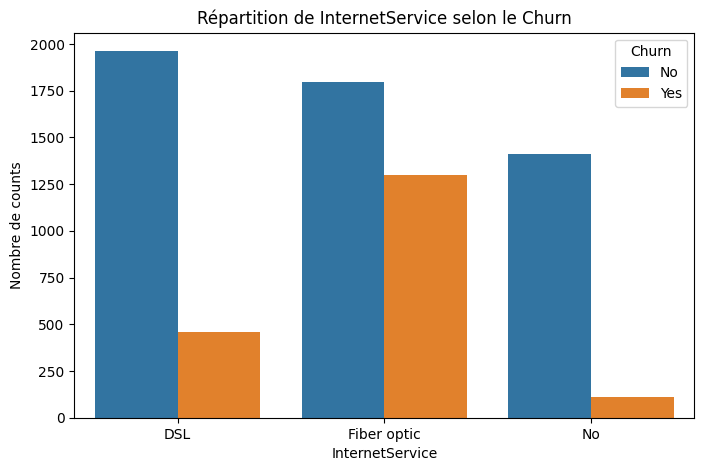

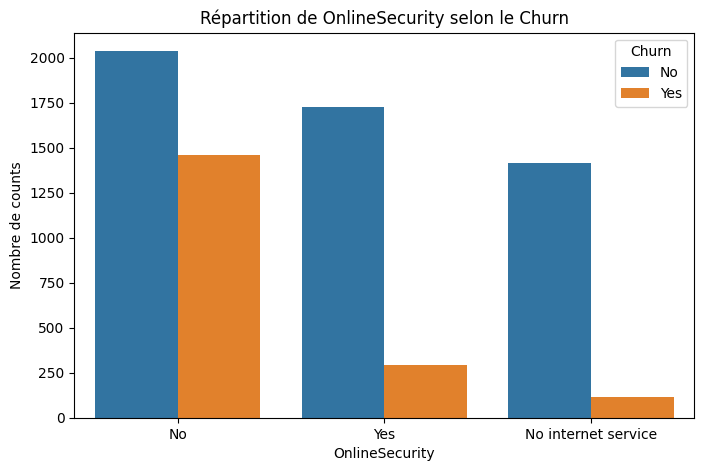

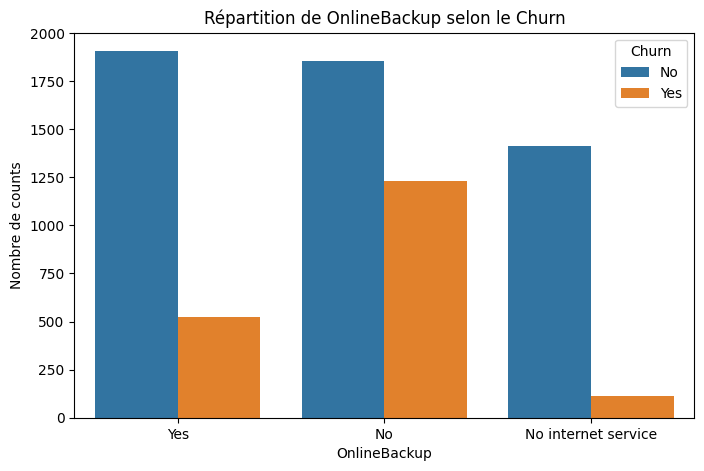

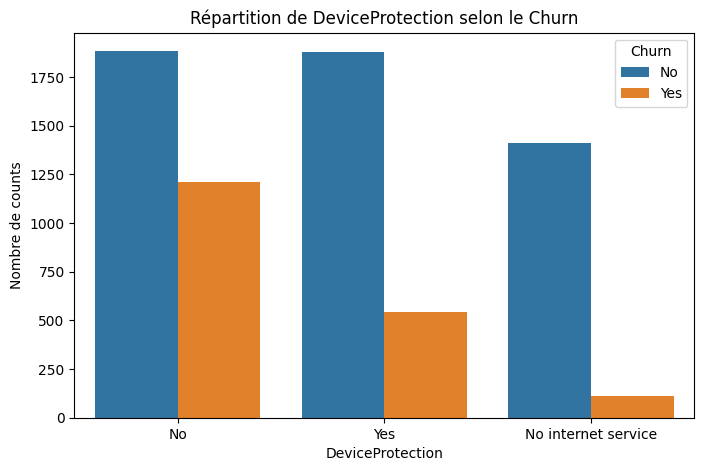

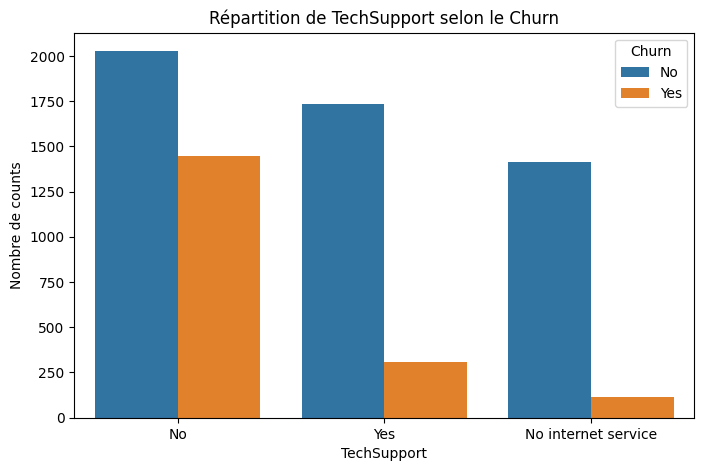

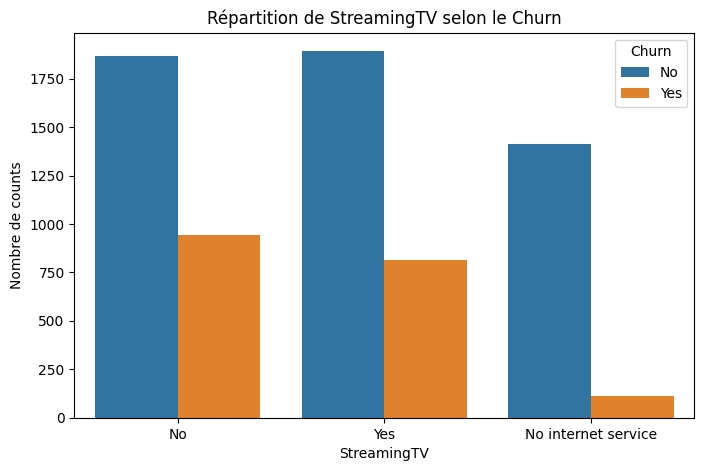

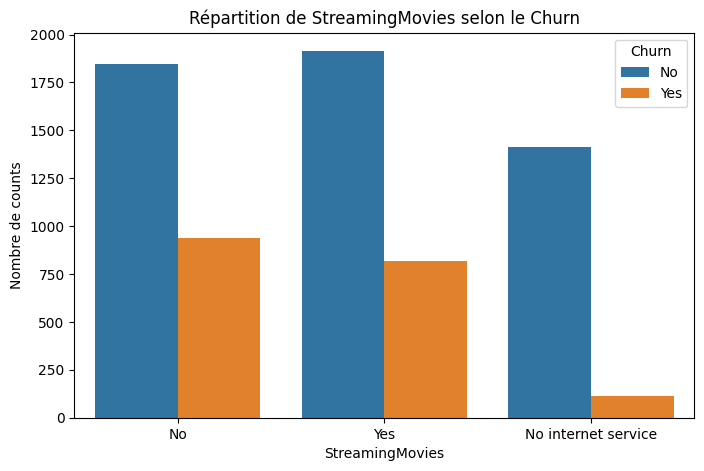

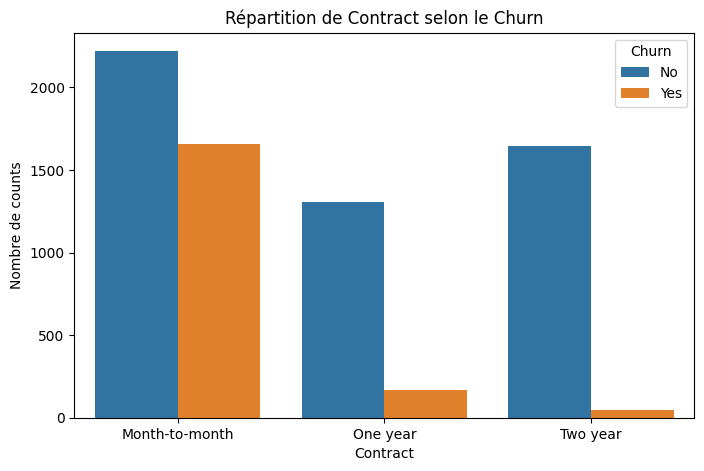

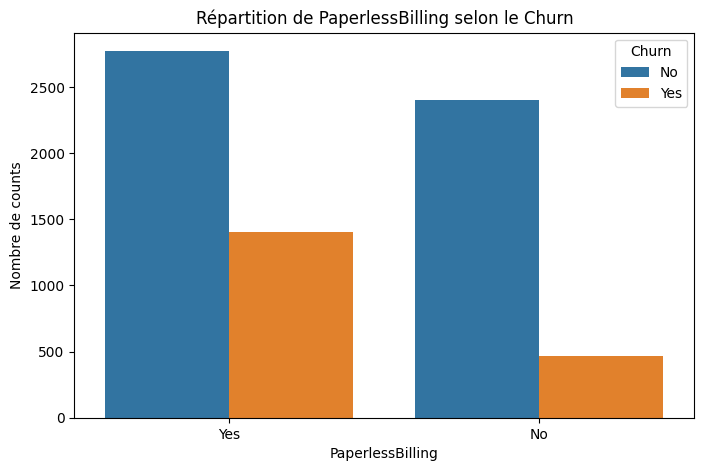

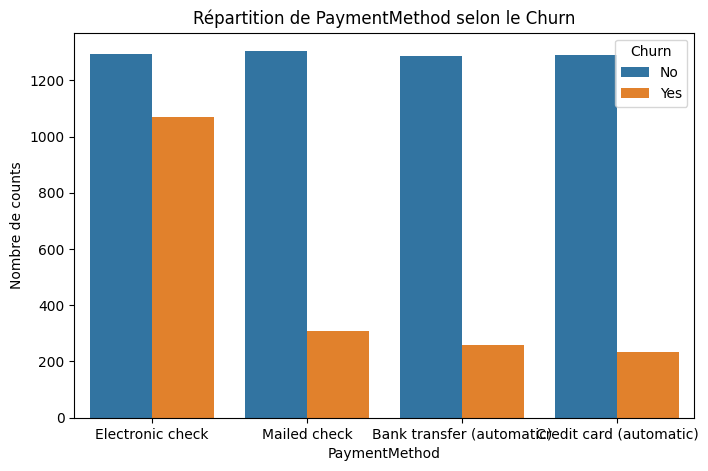

In [16]:
catg_cols = df.select_dtypes(include=['object', 'category']).columns
for col in catg_cols:
    if col != 'Churn':
        plot_countplot(df, column=col, hue='Churn')

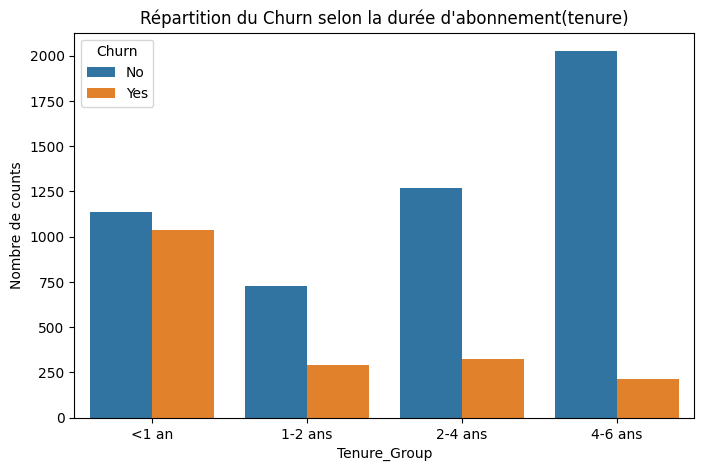

In [17]:
#Distribution du Churn selon la durée d'abonnement
# Tranches de durée
df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['<1 an', '1-2 ans', '2-4 ans', '4-6 ans'])

# Compter la répartition de Churn selon les tranches
plot_countplot(df,column='Tenure_Group',hue='Churn',title="Répartition du Churn selon la durée d'abonnement(tenure)")


## Matrice de corrélation

In [18]:
# Encode Churn to 0 ,1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

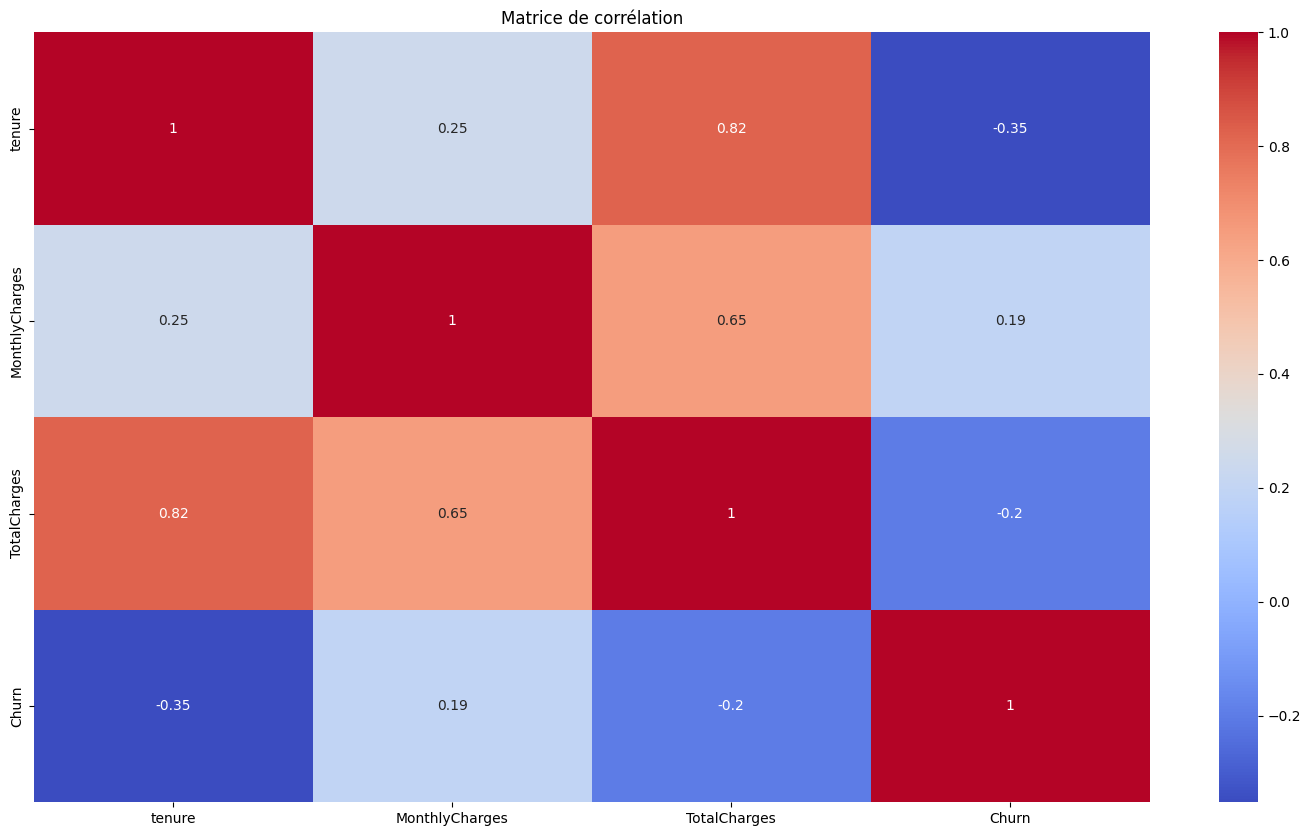

In [19]:
# Sélection des colonnes numériques
numeric_cols = df.select_dtypes(include='number')
numeric_cols = numeric_cols.drop(columns='SeniorCitizen', errors='ignore')
# Calcul de la matrice de corrélation
corr_matrix = numeric_cols.corr()

# Visualisation avec seaborn
plt.figure(figsize=(18,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()


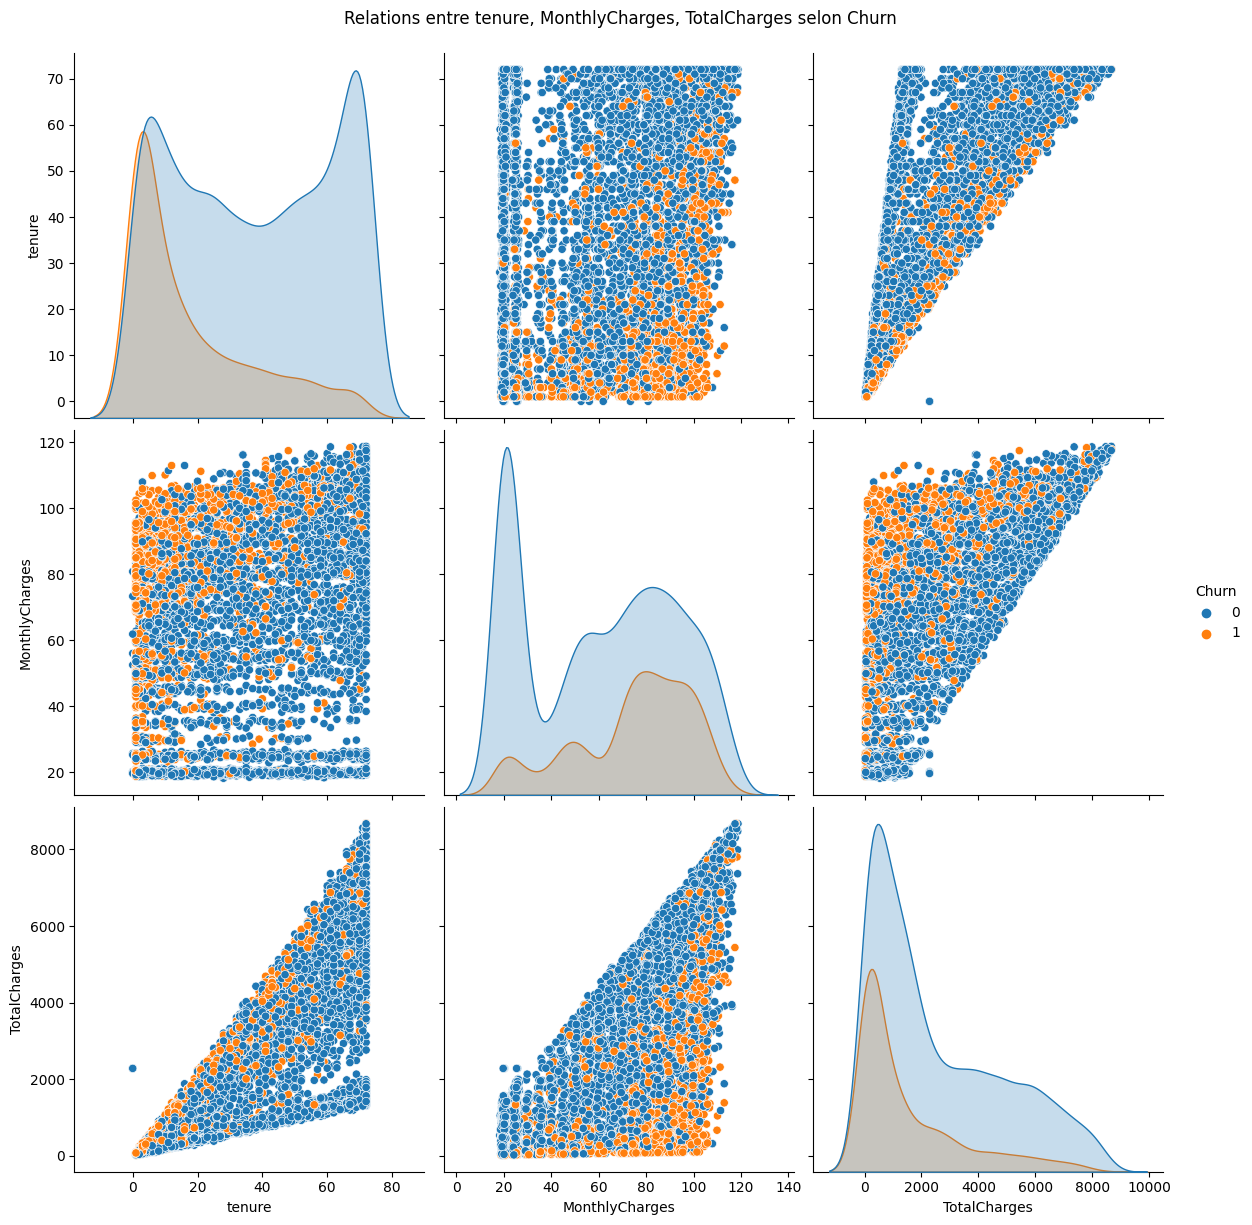

In [20]:
# Visualiser les Relations entre tenure, MonthlyCharges et TotalCharges selon le Churn
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','Churn']], hue='Churn',height=4,aspect=1)
plt.suptitle("Relations entre tenure, MonthlyCharges, TotalCharges selon Churn", y=1.02)
plt.show()
